# Storytelling Through Data - GitHub Over the Past Decade
### *A deep-dive exploration of the shifting landscape of open-source, and the impact of AI.*


This Notebook was submitted as part of the ***Springboard* Data Science Career Track** (Unit 29.3 - Apply Your Storytelling Skills).

---

## Introduction

In this Notebook, we'll be constructing an overview on GitHub trends using three different datasets:
- `github_top_developers_2015-2025.csv`: A dataset of top developers who appeared on GitHub's trending page, scraped across 41,841 snapshots from the *Wayback Machine*.

    ***Source**: https://www.kaggle.com/datasets/ronantakizawa/github-top-developers*
- `github_top_repos_2013-2025.csv`: A dataset of the top repositories which appeared on GitHub's trending page, also scraped from *Wayback Machine* snapshots.

    ***Source**: https://huggingface.co/datasets/ronantakizawa/github-top-projects*
- `github_ranking_2026-04-04.csv`: A dataset of the top 100 most starred repos as of today (April 4th, 2026).

    ***Source**: https://github.com/EvanLi/Github-Ranking*

The questions I'll be attempting to explore:
- What are the notable "eras" of open-source over the past decade?
- What sort of shifts can we observe as a result of AI?
- Are there any notable changes in developer leaderboard?
- Can we observe any microtrends within the AI space? Perhaps a shift from LLM tooling to agentic frameworks?
- What does the landscape look like today?

## 1. Data Wrangling & Cleaning

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
from datetime import datetime

sns.set_theme(style="dark", palette="Set3")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [2]:
devs = pd.read_csv("data/github_top_developers_2015-2025/github_top_developers_2015-2025.csv")
repos_full = pd.read_csv("data/github_top_repos_2013-2025/full/data.csv")
repos_monthly = pd.read_csv("data/github_top_repos_2013-2025/monthly/data.csv")
repos_2026 = pd.read_csv("data/github_top_repos_2026/github_ranking_2026-04-04.csv")

In [3]:
print(devs.shape)
devs.head()

(8125, 8)


,year,rank,name,times_trended,best_rank,avg_rank,median_rank,popular_repos
0,2025,1,comfyanonymous,18,2,11.72,11,comfyanonymous/ComfyUI
1,2025,2,emilk,12,1,8.17,6,"emilk/egui, emilk/eon"
2,2025,3,sxyazi,12,1,8.50,6,sxyazi/yazi
3,2025,4,elie222,9,1,3.33,2,elie222/inbox-zero
4,2025,5,yetone,15,3,12.87,14,yetone/avante.nvim


In [4]:
print(repos_full.shape)
repos_full.head()

(423098, 6)


,name,star_count,fork_count,repo_owner,rank,date
0,TrendRadar,32864.0,17842.0,sansan0,1,2025-11-30
1,adk-go,5474.0,366.0,google,2,2025-11-30
2,ChinaTextbook,59990.0,13354.0,TapXWorld,3,2025-11-30
3,cursor-free-vip,44261.0,5297.0,yeongpin,4,2025-11-30
4,nvm,90013.0,9624.0,nvm-sh,5,2025-11-30


In [5]:
print(repos_monthly.shape)
repos_monthly.head()

(3200, 8)


,month,rank,repository,repo_owner,repo_name,star_count,fork_count,ranking_appearances
0,2025-11,1,google/adk-go,google,adk-go,5494.0,366.0,55
1,2025-11,2,sansan0/TrendRadar,sansan0,TrendRadar,32930.0,17869.0,49
2,2025-11,3,TapXWorld/ChinaTextbook,TapXWorld,ChinaTextbook,60009.0,13357.0,52
3,2025-11,4,nvm-sh/nvm,nvm-sh,nvm,90021.0,9624.0,55
4,2025-11,5,yeongpin/cursor-free-vip,yeongpin,cursor-free-vip,44271.0,5298.0,46


In [6]:
print(repos_2026.shape)
repos_2026.head()

(3600, 11)


,rank,item,repo_name,stars,forks,language,repo_url,username,issues,last_commit,description
0,1,top-100-stars,build-your-own-x,485939,45711,Markdown,https://github.com/codecrafters-io/build-your-...,codecrafters-io,243,2026-02-21T09:34:54Z,Master programming by recreating your favorite...
1,2,top-100-stars,awesome,451626,33946,NaN,https://github.com/sindresorhus/awesome,sindresorhus,15,2026-04-02T16:30:33Z,😎 Awesome lists about all kinds of interesting...
2,3,top-100-stars,freeCodeCamp,440760,44007,TypeScript,https://github.com/freeCodeCamp/freeCodeCamp,freeCodeCamp,118,2026-04-03T22:40:32Z,freeCodeCamp.org's open-source codebase and cu...
3,4,top-100-stars,public-apis,418862,45543,Python,https://github.com/public-apis/public-apis,public-apis,3,2026-03-18T16:28:22Z,A collective list of free APIs
4,5,top-100-stars,free-programming-books,384969,66086,Python,https://github.com/EbookFoundation/free-progra...,EbookFoundation,35,2026-03-31T21:15:26Z,:books: Freely available programming books


Let's start with renaming features, adding some convinience features and dropping whichever ones we don't need.

In [7]:
# Renaming columns for consistency
devs.rename(columns={"name": "dev_name"}, inplace=True)
repos_full.rename(columns={"name": "repo_name", "repo_owner": "dev_name"}, inplace=True)
repos_monthly.rename(columns={"repo_owner": "dev_name", "ranking_appearances": "times_trended"}, inplace=True)
repos_2026.rename(columns={"stars": "star_count", "forks": "fork_count", "username": "dev_name"}, inplace=True)

In [8]:
def split_repo_names(popular_repos: str) -> list[str]:
    """Split the developer `popular_repos` feature into a list of repo names."""

    repo_names = []
    if popular_repos:
        for part in str(popular_repos).split(","):
            part = part.strip().lower()
            if "/" in part:
                part = part.split("/")[-1]
            repo_names.append(part)

    return repo_names


devs['has_repos'] = devs['popular_repos'].notnull()
devs['popular_repos'] = devs['popular_repos'].apply(split_repo_names)

devs.info()

<class 'pandas.DataFrame'>
RangeIndex: 8125 entries, 0 to 8124
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           8125 non-null   int64  
 1   rank           8125 non-null   int64  
 2   dev_name       8125 non-null   str    
 3   times_trended  8125 non-null   int64  
 4   best_rank      8125 non-null   int64  
 5   avg_rank       8125 non-null   float64
 6   median_rank    8125 non-null   int64  
 7   popular_repos  8125 non-null   object 
 8   has_repos      8125 non-null   bool   
dtypes: bool(1), float64(1), int64(5), object(1), str(1)
memory usage: 515.9+ KB


In [9]:
# Converting 'date' to datetime and extracting month and year.
repos_full['date'] = pd.to_datetime(repos_full['date'])
repos_full['month'] = repos_full['date'].dt.to_period("M")
repos_full['year'] = repos_full['date'].dt.year

repos_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 423098 entries, 0 to 423097
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   repo_name   423098 non-null  str           
 1   star_count  397948 non-null  float64       
 2   fork_count  397929 non-null  float64       
 3   dev_name    423098 non-null  str           
 4   rank        423098 non-null  int64         
 5   date        423098 non-null  datetime64[us]
 6   month       423098 non-null  period[M]     
 7   year        423098 non-null  int32         
dtypes: datetime64[us](1), float64(2), int32(1), int64(1), period[M](1), str(2)
memory usage: 24.2 MB


In [10]:
# Converting 'month' to datetime and extracting year.
repos_monthly['month'] = pd.to_datetime(repos_monthly['month']).dt.to_period("M")
repos_monthly['year'] = repos_monthly['month'].dt.year

repos_monthly.info()

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   month          3200 non-null   period[M]
 1   rank           3200 non-null   int64    
 2   repository     3200 non-null   str      
 3   dev_name       3200 non-null   str      
 4   repo_name      3200 non-null   str      
 5   star_count     2169 non-null   float64  
 6   fork_count     2169 non-null   float64  
 7   times_trended  3200 non-null   int64    
 8   year           3200 non-null   int64    
dtypes: float64(2), int64(3), period[M](1), str(3)
memory usage: 225.1 KB


In [11]:
# 'item' represents the top 100 list we're pulling from, with one for each language.
repos_2026 = repos_2026[repos_2026['item'] == "top-100-stars"]
# We're really just interested in the top 100 repos, so we'll drop the rest, as well as other unnecessary columns.
repos_2026 = repos_2026.drop(columns=["item", "repo_url", "description"])
# Converting 'last_commit' to datetime.
repos_2026['last_commit'] = pd.to_datetime(repos_2026['last_commit'])

repos_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   rank         100 non-null    int64              
 1   repo_name    100 non-null    str                
 2   star_count   100 non-null    int64              
 3   fork_count   100 non-null    int64              
 4   language     87 non-null     str                
 5   dev_name     100 non-null    str                
 6   issues       100 non-null    int64              
 7   last_commit  100 non-null    datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), int64(4), str(3)
memory usage: 6.4 KB


### ChatGPT Labels

I used ChatGPT Codex generate a list of labels with helper functions in `ai_labels.py`. This will allow us to more roughly differentiate between repos that pertain to AI/agentic workflows, as well as classify each repo into a broad "theme" bucket.

In [12]:
from ai_labels import (
    THEMES,
    classify_theme,
    is_agentic_repo,
    is_ai_repo,
    is_corp_dev,
    is_startup_dev
)

print(THEMES)

['Frameworks and UI', 'DevOps / infra', 'Languages / libraries', 'Learning resources', 'Developer tools', 'AI / ML', 'Agentic', 'Current events / social', 'Other']


In [13]:
# Adding columns to repo dataframes for AI-booleans and theme classification.
for df in [repos_full, repos_monthly, repos_2026]:
    df['is_ai'] = df['repo_name'].apply(is_ai_repo)
    df['is_agentic'] = df['repo_name'].apply(is_agentic_repo)
    df['theme'] = df['repo_name'].apply(classify_theme)

repos_full[['repo_name', 'is_ai', 'is_agentic', 'theme']].head()

,repo_name,is_ai,is_agentic,theme
0,TrendRadar,False,False,[Other]
1,adk-go,True,True,"[AI / ML, Agentic]"
2,ChinaTextbook,False,False,[Learning resources]
3,cursor-free-vip,True,True,"[AI / ML, Agentic]"
4,nvm,False,False,[Developer tools]


In [14]:
# Adding columns to dev dataframe for AI/agentic relation and corp/startup classification.
def compute_related(popular_repos: list[str], has_repos: bool, matcher):
    related = pd.NA
    if has_repos:
        related = any(matcher(repo) for repo in popular_repos)
    return related

devs['ai_related'] = devs.apply(
    lambda row: compute_related(row['popular_repos'], row['has_repos'], is_ai_repo),
    axis=1,
).astype('boolean')
devs['agentic_related'] = devs.apply(
    lambda row: compute_related(row['popular_repos'], row['has_repos'], is_agentic_repo),
    axis=1,
).astype('boolean')


# Adding columns for corp/startup classification.
devs['is_corp'] = devs['dev_name'].apply(is_corp_dev)
devs['is_startup'] = devs['dev_name'].apply(is_startup_dev)

devs[['dev_name', 'ai_related', 'agentic_related', 'is_corp', 'is_startup']].head()

,dev_name,ai_related,agentic_related,is_corp,is_startup
0,comfyanonymous,True,False,False,False
1,emilk,False,False,False,False
2,sxyazi,False,False,False,False
3,elie222,False,False,False,False
4,yetone,True,True,False,False


## 2. Important Dates, Scope, and Considerations

Some important considerations to keep in mind in regards to our data:
- The *github_top_repos_2013-2025* data comes from Wayback Machine snapshots of GitHub's ***Trending page***, so it's more a measure of what was gathering people's attention at the time of the snapshot, rather than a complete look at the state of GitHub.
- The density of snapshots tends to vary for different time periods. This means to compare across different time periods it will be best to avoid cumulative features such as `times_trended` and focus more on the ratio of appearances within the its given time frame.
- There's quite a few `star_count` and `fork_count` values missing from *github_top_repos_2013-2025*. It appears that counts began after 2020, and are also time inconsistent due to snapshot density. For this reason, we'll focus on the monthly ranking position for long-term comparative measures.
- The *github_top_developers_2015-2025* data only includes `popular_repos` from 2018 onward, so repo-theme analysis for developers should start from there.


In [15]:
snapshot_density = repos_full.groupby("month").size()
print(
    "Trending snapshot density ranges from "
    f"{snapshot_density.min():,} to {snapshot_density.max():,} rows per month."
)
print(
    "Share of rows with missing star counts before 2020:",
    f"{repos_full.loc[repos_full['year'] < 2020, 'star_count'].isna().mean():.1%}",
)
print(
    "Share of rows with missing star counts in 2020+:",
    f"{repos_full.loc[repos_full['year'] >= 2020, 'star_count'].isna().mean():.1%}",
)
print(
    "Share of devs with missing repos before 2018:",
    f"{(devs.loc[devs['year'] < 2018, 'has_repos'] == False).mean():.1%}",
)
print(
    "Share of devs with missing repos in 2018+:",
    f"{(devs.loc[devs['year'] >= 2018, 'has_repos'] == False).mean():.1%}",
)

Trending snapshot density ranges from 25 to 17,446 rows per month.
Share of rows with missing star counts before 2020: 100.0%
Share of rows with missing star counts in 2020+: 0.0%
Share of devs with missing repos before 2018: 100.0%
Share of devs with missing repos in 2018+: 15.9%


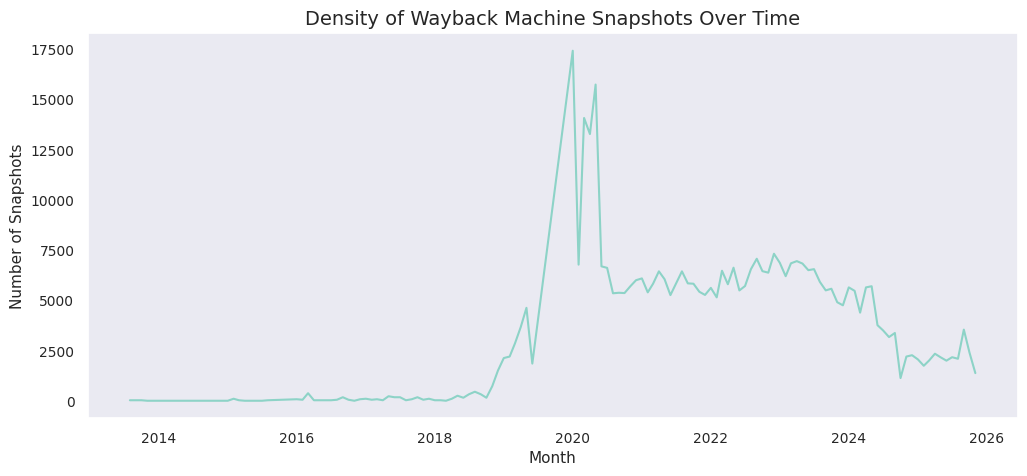

In [16]:
plot_density = snapshot_density.copy()
plot_density.index = plot_density.index.to_timestamp()

plt.figure(figsize=(12, 5))
sns.lineplot(x=plot_density.index, y=plot_density.values)
plt.title("Density of Wayback Machine Snapshots Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Snapshots")
plt.show()

Here's a (admittedly packed but) condensed timeline of notable AI releases over the past decade:
- (*Google*) TensorFlow open-source release: November 9, 2015
- (*Meta*) PyTorch open-source release: September 1, 2016
- (*OpenAI*) GPT-3 API beta release: June 11, 2020
- (*Microsoft*) GitHub Copilot beta release: June 29, 2021
- (*OpenAI*) GPT-3 API public release: November 18, 2021
- (*Microsoft*) GitHub Copilot public release: June 21, 2022
- (*indie*) LangChain open-source release: October, 2022
- (*OpenAI*) ChatGPT release: November 30, 2022
- (*startup*) Cursor public release: March, 2023
- (*OpenAI*) GPT-4 release: March 14, 2023
- (*startup*) AutoGPT open-source release: March 30, 2023
- (*Anthropic*) Claude 3.5 Sonnet release: June 20, 2024
- (*DeepSeek*) DeepSeek R1 release: January 20, 2025
- (*Anthropic*) Claude Code public release: May 22, 2025
- (*indie*) OpenCode open-source release: June 19, 2025

In [17]:
release_dates = {
    "TensorFlow open-source release": datetime(2015, 11, 9),
    "PyTorch open-source release": datetime(2016, 9, 1),
    "GPT-3 API beta release": datetime(2020, 6, 11),
    "GitHub Copilot beta release": datetime(2021, 6, 29),
    "GPT-3 API public release": datetime(2021, 11, 18),
    "GitHub Copilot public release": datetime(2022, 6, 21),
    "LangChain open-source release": datetime(2022, 10, 1),
    "ChatGPT release": datetime(2022, 11, 30),
    "Cursor public release": datetime(2023, 3, 1),
    "GPT-4 release": datetime(2023, 3, 14),
    "AutoGPT open-source release": datetime(2023, 3, 30),
    "Claude 3.5 Sonnet release": datetime(2024, 6, 20),
    "DeepSeek R1 release": datetime(2025, 1, 20),
    "Claude Code public release": datetime(2025, 5, 22),
    "OpenCode open-source release": datetime(2025, 6, 19),
}

## 3. Monthly Trending Page Eras: From Frameworks to Agents

We'll start with taking a closer look at `repos_monthly`. This dataset will provide us with a cleaner overall look at the trends throughout the year, since each month contributes the same number of leaderboard slots.


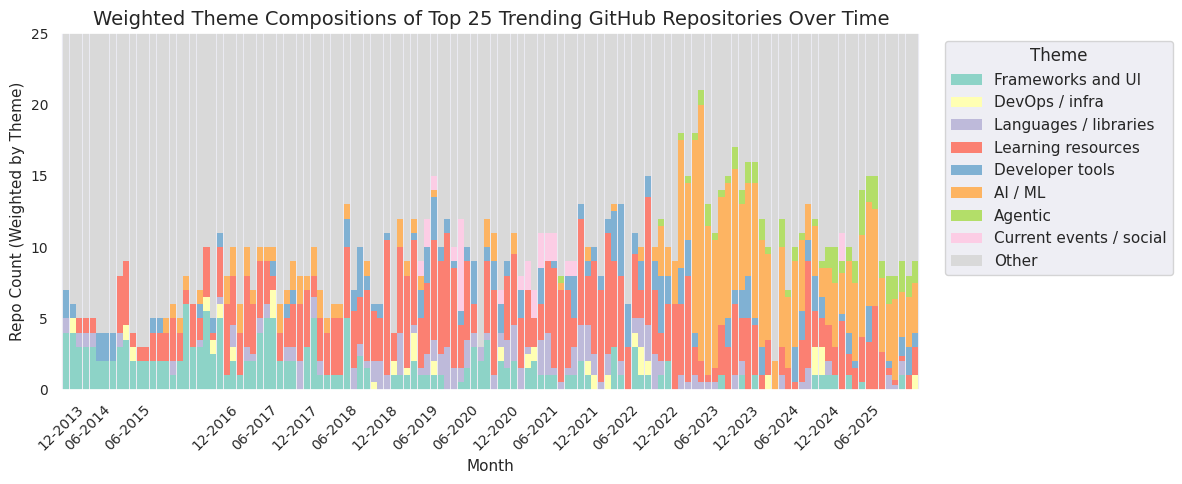

In [18]:
# New copy of repos_monthly for plotting, with datetime month for better x-axis formatting.
repos_monthly_plot = repos_monthly.copy()
repos_monthly_plot['month'] = repos_monthly_plot['month'].dt.to_timestamp()
# Sort by month and rank
repos_monthly_plot.sort_values(["month", "rank"], ascending=[True, True], inplace=True)
# Normalize themes to lists so explode and weighting stay in sync with the helper above.
repos_monthly_plot['theme'] = repos_monthly_plot['theme'].apply(
    lambda x: x if isinstance(x, list) else ([x] if pd.notna(x) else [])
)
repos_monthly_plot = repos_monthly_plot.loc[repos_monthly_plot['theme'].str.len() > 0].copy()
# New column for number of themes
repos_monthly_plot['num_themes'] = repos_monthly_plot['theme'].str.len()
# Explode to one row per theme
repos_monthly_plot = repos_monthly_plot.explode('theme')

# Assign fractional weight to themes so each repo contributes equally to the plot regardless of theme count.
repos_monthly_plot['theme_weight'] = 1 / repos_monthly_plot['num_themes']
# Keep the preferred theme order from THEMES, but still include any unexpected labels found in the data.
theme_order = [theme for theme in THEMES if theme in repos_monthly_plot['theme'].unique()]
theme_order += sorted(set(repos_monthly_plot['theme']) - set(theme_order))

# Sum weighted theme contributions by month and reshape into a wide format for stacked bar plotting.
weighted_themes_per_month = (
    repos_monthly_plot.groupby(["month", "theme"])['theme_weight']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=theme_order, fill_value=0)
    )

# Plot the weighted monthly theme mix as a stacked bar chart with seamless color blocks.
ax = weighted_themes_per_month.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    width=0.9,
    edgecolor="none",
    linewidth=0
)
# Show x-axis labels only for June and December to keep the timeline readable.
semiannual_positions = [
    i for i, month in enumerate(weighted_themes_per_month.index)
    if month.month in {6, 12}
]
semiannual_labels = [
    weighted_themes_per_month.index[i].strftime("%m-%Y")
    for i in semiannual_positions
]
# Apply the reduced set of formatted tick labels to the x-axis.
ax.set_xticks(semiannual_positions)
ax.set_xticklabels(semiannual_labels, rotation=45, ha="right")
# Match the y-axis to the top-25 leaderboard and remove grid lines for a cleaner stacked look.
ax.set_ylim(0, 25)
# Add the chart title, axis labels, and legend placement.
ax.set_title("Weighted Theme Compositions of Top 25 Trending GitHub Repositories Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Repo Count (Weighted by Theme)")
ax.legend(title="Theme", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Let's start to take a look at the most popular repos of each year to try to get a feel for the "eras". We'll first breakdown the percentage distribution of each theme per year, and then try to see which "repo leaders" appear each year to help set the tone for what that point in time represents.

In [19]:
# Adding 'score' feature which represents the inverse of the rank (higher ranks equal higher scores).
repos_monthly['score'] = 26 - repos_monthly['rank']

# Aggregating monthly scores to compute annual scores, number of months trended, and best rank for each repo-year combination.
annual_repo_scores = (
    repos_monthly.groupby(["year", "repository"], as_index=False)
    .agg(
        annual_score=("score", "sum"),
        num_months_trended=("month", "nunique"),
        best_rank=("rank", "min"),
        theme=("theme", "first"),
    )
)

# Sorting by year, annual score, months trended, and best rank to identify top performers each year.
annual_repo_scores = annual_repo_scores.sort_values(
    ["year", "annual_score", "num_months_trended", "best_rank"],
    ascending=[True, False, False, True],
).reset_index(drop=True)
annual_repo_scores

,year,repository,annual_score,num_months_trended,best_rank,theme
0,2013,twbs/bootstrap,84,4,2,[Frameworks and UI]
1,2013,angular/angular.js,63,4,7,[Frameworks and UI]
2,2013,jquery/jquery,57,4,5,[Other]
3,2013,vhf/free-programming-books,50,2,1,[Learning resources]
4,2013,kkga/spacegray,48,2,2,[Other]
...,...,...,...,...,...,...
2553,2025,gin-gonic/gin,1,1,25,[Other]
2554,2025,google/googletest,1,1,25,[Other]
2555,2025,musistudio/claude-code-router,1,1,25,"[AI / ML, Agentic]"
2556,2025,sst/opentui,1,1,25,[Other]


In [20]:
# Calculating the percentage of top trending repos in each theme for each year, accounting for multi-theme repos with fractional weights.
annual_theme_percentages = annual_repo_scores[["year", "repository", "theme"]].copy()
# Normalize themes to lists so multi-theme repos can be split evenly across their labels.
annual_theme_percentages["theme"] = annual_theme_percentages["theme"].apply(
    lambda x: x if isinstance(x, list) else ([x] if pd.notna(x) else [])
)
# Filter out repo-years with no themes to avoid skewing the percentage calculations.
annual_theme_percentages = annual_theme_percentages.loc[
    annual_theme_percentages["theme"].str.len() > 0
].copy()
# Count how many themes each repo-year has before exploding the lists.
annual_theme_percentages["num_themes"] = annual_theme_percentages["theme"].str.len()
# Explode so each row represents one repo-year/theme pair.
annual_theme_percentages = annual_theme_percentages.explode("theme")
# Give each repo-year a total weight of 1, split evenly across however many themes it has.
annual_theme_percentages["theme_weight"] = 1 / annual_theme_percentages["num_themes"]
# Keep the preferred theme order from THEMES, but still include any unexpected labels found in the data.
annual_theme_order = [theme for theme in THEMES if theme in annual_theme_percentages["theme"].unique()]
annual_theme_order += sorted(set(annual_theme_percentages["theme"]) - set(annual_theme_order))
# Sum weighted theme contributions within each year and convert them to percentages.
annual_theme_percentages = (
    annual_theme_percentages.groupby(["year", "theme"])["theme_weight"]
    .sum()
    .groupby(level=0)
    .transform(lambda s: s / s.sum() * 100)
    .rename("percentage")
    .reset_index()
)
annual_theme_percentages["percentage"] = annual_theme_percentages["percentage"].round(2)
# Pivot to a year-by-theme table for easier comparison across years.
annual_theme_percentages = (
    annual_theme_percentages.pivot(index="year", columns="theme", values="percentage")
    .reindex(columns=annual_theme_order, fill_value=0)
    .fillna(0)
)

annual_theme_percentages

theme,Frameworks and UI,DevOps / infra,Languages / libraries,Learning resources,Developer tools,AI / ML,Agentic,Current events / social,Other
year,,,,,,,,,
2013,9.09,1.82,3.64,1.82,5.45,0.00,0.00,0.00,78.18
2014,9.59,0.00,2.74,5.48,2.74,0.00,0.00,0.00,79.45
2015,8.61,1.64,0.00,6.97,0.82,0.82,0.00,0.00,81.15
2016,11.91,1.56,1.37,7.03,1.17,3.12,0.00,0.00,73.83
2017,9.92,0.79,2.78,9.92,1.19,2.38,0.00,0.00,73.02
2018,3.81,0.65,3.38,14.37,3.66,1.29,0.00,0.00,72.84
2019,4.96,2.89,2.48,15.29,6.20,2.89,0.00,1.65,63.64
2020,5.33,0.41,4.71,13.52,4.30,2.25,0.00,3.07,66.39
2021,3.54,1.67,3.75,12.08,4.17,0.62,0.21,3.96,70.00


This already tells us a lot, but let's try to visualize it.

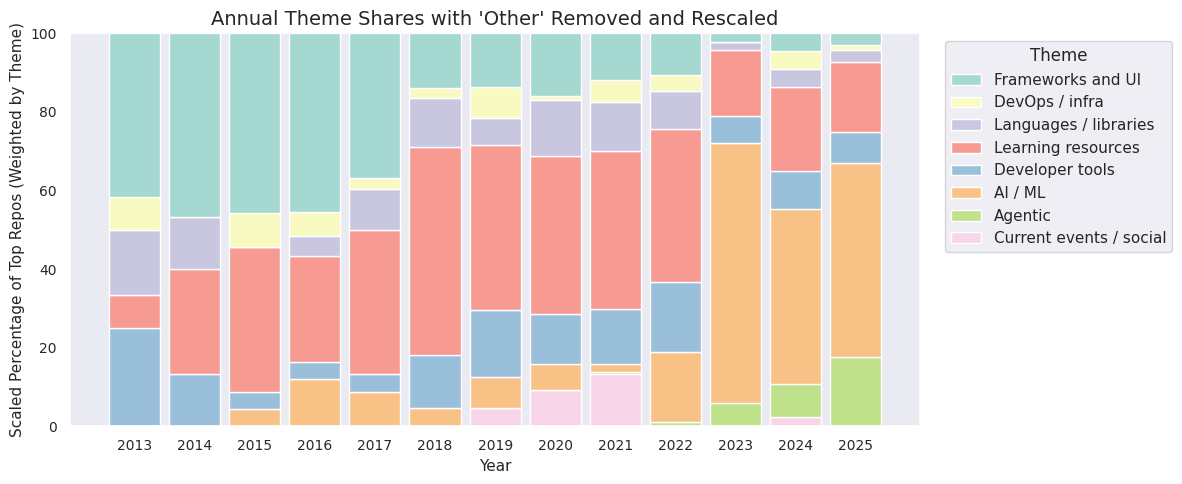

In [21]:
# Drop the "Other" column, then rescale each year so the remaining themes sum to 100%.
annual_theme_percentages_plot = annual_theme_percentages.drop(columns=["Other"], errors="ignore")
annual_theme_percentages_plot = annual_theme_percentages_plot.div(
    annual_theme_percentages_plot.sum(axis=1).replace(0, pd.NA),
    axis=0,
).mul(100)
# Reshape the table into long format so seaborn can plot one stacked histogram bar per year.
annual_theme_percentages_long = (
    annual_theme_percentages_plot.reset_index()
    .melt(id_vars="year", var_name="theme", value_name="percentage")
    .dropna(subset=["percentage"])
)
# Plot the rescaled yearly theme shares with years on the x-axis and percentages on the y-axis.
plt.figure(figsize=(12, 5))
ax = sns.histplot(
    data=annual_theme_percentages_long,
    x="year",
    weights="percentage",
    hue="theme",
    hue_order=[theme for theme in annual_theme_order if theme != "Other"],
    multiple="stack",
    discrete=True,
    stat="count",
    shrink=0.85,
    alpha=0.75,
    edgecolor=None,
)
ax.set_ylim(0, 100)
ax.set_xticks(sorted(annual_theme_percentages_plot.index))
ax.set_title("Annual Theme Shares with 'Other' Removed and Rescaled")
ax.set_xlabel("Year")
ax.set_ylabel("Scaled Percentage of Top Repos (Weighted by Theme)")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="Theme")
plt.tight_layout()
plt.show()

Here we can see a pretty clear pattern of "eras" emerging:
- **2013-2017** is sort of the "*Framework & UI Infrastructure*" era. This is the time period where the foundational open-source building blocks that make up the modern web stack began taking shape.
- **2017-2022** is a "*Learn-to-code Gold Rush*" era. Online resources for career roadmaps, interview preps, DSA repos, were becoming much more popular as the field of software engineering saw a huge uptick in popularity.
- **2023** is the "*AI Inflection Point*". This year saw an absolute explosion in AI/ML related repos, likely immediately following the release of more mainstream LLM interfacing tools such as **ChatGPT** and **Cursor**.
- **2025** is the real beginning of the "*Agentic AI*" era. Still an AI dominated era, but we're seeing a slow swelling of agentic proejcts with the growing interest in copilots, agents, orchestration tools, MCPs, etc.

In [22]:
# Looking at the top 5 repos each year to see if we can spot any interesting patterns in the themes of the most dominant annual performers.
annual_repo_scores_top_5 = (
    annual_repo_scores.sort_values(
        ["year", "annual_score", "num_months_trended", "best_rank"],
        ascending=[True, False, False, True],
    )
    .groupby("year", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

for year, top_repos in annual_repo_scores_top_5.groupby("year"):
    print(f"\nTop 5 repos in {year}:")
    for _, row in top_repos.iterrows():
        print(f"- {row['repository']}: {row['annual_score']:.2f}")



Top 5 repos in 2013:
- twbs/bootstrap: 84.00
- angular/angular.js: 63.00
- jquery/jquery: 57.00
- vhf/free-programming-books: 50.00
- kkga/spacegray: 48.00

Top 5 repos in 2014:
- atom/atom: 75.00
- quilljs/quill: 72.00
- topcloud/socketcluster: 69.00
- packetbeat/packetbeat: 66.00
- atom/atom-shell: 63.00

Top 5 repos in 2015:
- DanielRapp/doppler: 50.00
- facebook/nuclide: 50.00
- google/fonts: 48.00
- mattermost/platform: 48.00
- FreeCodeCamp/freecodecamp: 46.00

Top 5 repos in 2016:
- FreeCodeCamp/FreeCodeCamp: 220.00
- tensorflow/tensorflow: 55.00
- jwasham/google-interview-university: 44.00
- hollance/swift-algorithm-club: 40.00
- jiahaog/nativefier: 38.00

Top 5 repos in 2017:
- tensorflow/tensorflow: 213.00
- vuejs/vue: 108.00
- freeCodeCamp/freeCodeCamp: 75.00
- mr-mig/every-programmer-should-know: 70.00
- k88hudson/git-flight-rules: 47.00

Top 5 repos in 2018:
- trekhleb/javascript-algorithms: 79.00
- kelseyhightower/nocode: 75.00
- kusti8/proton-native: 72.00
- bradley/Blot

The top repos of each year seem to loosely align with our era identities. Some notable repos per era are:
1. *Framework & UI Infrastructure* (2013-2017):
    - `twbs/bootstrap`
    - `angular/angular`
    - `jquery/jquery`
    - `atom/atom`
    - `vuejs/vue`

2. *Learn-to-code Gold Rush* (2017-2022):
    - `FreeCodeCamp/FreeCodeCamp` (*notably peaks in popularity around 2016, but remains highly ranked in 2017*)
    - `mr-mig/every-programmer-should-know`
    - `trekhleb/javascript-algorithms`
    - `TheAlgorithms/Python`

3. *AI Inflection Point* (2023-2024):
    - `jmorganca/ollama`
    - `Pythagora-io/gpt-pilot`
    - `microsoft/generative-ai-for-beginners`
    - `fishaudio/fish-speech`

4. *Agentic AI* (2025):
    - `virattt/ai-hedge-fund`
    - `Shubhamsaboo/awesome-llm-apps`

One notable outlier is `tensorflow/tensorflow` which appears far earlier than the rest of the AI surge.

## 4. When Did AI Become a Sustained Share of Trending?

The monthly trending repos paints a nice picture of what our eras might look like. It's worth noting that the theme labels are noticably heuristic and conservative. A good amount of the "Other" category likely contains items that may have been better categorized with a more detailed comb over. But the goal is not a perfect taxonomy; it's to observe the slow and then explosive portion of open-source development efforts being expended in the AI and agentic space.

To really look at this establishment and persistence in full, we'll take a a look at the share of all daily trending slots that were occupied by AI-tagged repositories in `repos_full`. We'll also have a look at some dates that align with our charts for an extra layer of storytelling.


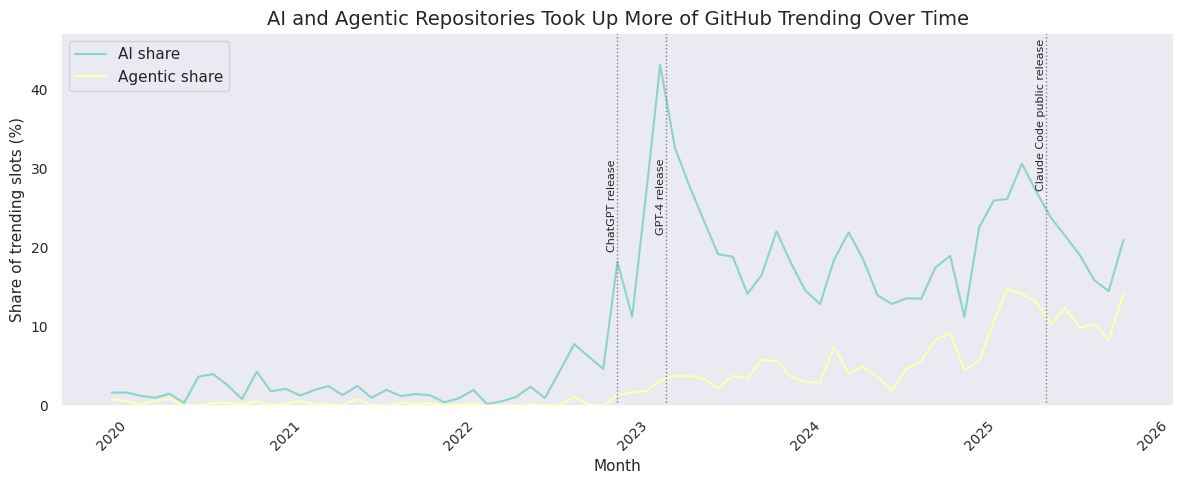

In [23]:
monthly_ai_share = repos_full.groupby("month")[["is_ai", "is_agentic"]].mean() * 100
plot_share = monthly_ai_share.loc["2020-01":].copy()
plot_share.index = plot_share.index.to_timestamp()

important_dates = {
    "ChatGPT release": release_dates["ChatGPT release"],
    "GPT-4 release": release_dates["GPT-4 release"],
    "Claude Code public release": release_dates["Claude Code public release"],
}

y_max = plot_share[["is_ai", "is_agentic"]].max().max()
label_positions = [y_max * 0.45, y_max * 0.5, y_max * 0.63]

plt.figure(figsize=(12, 5))
plt.plot(plot_share.index, plot_share["is_ai"], label="AI share")
plt.plot(plot_share.index, plot_share["is_agentic"], label="Agentic share")

for (label, date), label_y in zip(important_dates.items(), label_positions):
    plt.axvline(date, color="gray", linestyle=":", linewidth=1)
    plt.text(date, label_y, label, rotation=90, va="bottom", ha="right", fontsize=8)

plt.title("AI and Agentic Repositories Took Up More of GitHub Trending Over Time")
plt.xlabel("Month")
plt.ylabel("Share of trending slots (%)")
plt.ylim(0, y_max + 4)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can observe some pretty interesting reactions to our dates here:
- The **release of ChatGPT** in late 2022 was immediately followed by a tremendous spike in AI share.
- The **release of GPT 4** is not directly indicative of a spike, in fact AI share went down shortly after. But the relative minimum that was sustained set a much higher baseline than before, likely as a result of the continuously increasing capabilities of LLM models.
- The **release of Claude Code** is a pretty sweet point to observe. You can see that prior to its release, the agentic share would scale nearly identically with the AI share. Immediately after its release you can see the agentic share establishes a hold of its own.

## 5. From Corporate to Indie: Shifts in Developer Popularity

The repository story could suggest we might see a couple things with the developer trending page:
1. AI-related maintainers should start occupying more of the developer leaderboard.
2. The *style* of the leaderboard may shift from organizations to single indie developers backed by agentic programming.

In [24]:
selected_years = range(2018, 2026)
yearly_top_devs = []

for year in selected_years:
    sample = (
        devs.loc[devs["year"] == year, ["rank", "dev_name", "times_trended", "popular_repos"]]
        .sort_values("rank")
        .head(10)
        .copy()
    )
    sample.insert(0, "year", year)
    yearly_top_devs.append(sample)

yearly_top_devs = pd.concat(yearly_top_devs, ignore_index=True)
yearly_top_devs

,year,rank,dev_name,times_trended,popular_repos
0,2018,1,google,15,[material-design-icons]
1,2018,2,Microsoft,15,[vscode]
2,2018,3,facebook,15,[react]
3,2018,4,apache,15,[incubator-echarts]
4,2018,5,tensorflow,15,[tensorflow]
...,...,...,...,...,...
75,2025,6,hiyouga,11,[llama-factory]
76,2025,7,hrydgard,9,[ppsspp]
77,2025,8,jlowin,10,[fastmcp]
78,2025,9,azure-sdk,12,"[github-event-processor-test, mcp, azure-docs-..."


In [25]:

top_devs = devs.loc[(devs["year"] >= 2018) & (devs["rank"] <= 25)].copy()
top_devs["is_indie"] = (~top_devs["is_corp"]) & (~top_devs["is_startup"])

developer_ai_share = (
    top_devs.groupby("year")
    .agg(
        ai_share=("ai_related", "mean"),
        agentic_share=("agentic_related", "mean"),
        corp_share=("is_corp", "mean"),
        startup_share=("is_startup", "mean"),
        indie_share=("is_indie", "mean"),
    )
    .mul(100)
    .round(1)
)
developer_ai_share

,ai_share,agentic_share,corp_share,startup_share,indie_share
year,,,,,
2018,4.0,0.0,28.0,0.0,72.0
2019,8.0,0.0,24.0,0.0,76.0
2020,4.0,4.0,0.0,0.0,100.0
2021,4.0,4.0,0.0,0.0,100.0
2022,0.0,0.0,4.0,0.0,96.0
2023,32.0,4.0,4.0,0.0,96.0
2024,28.0,12.0,4.0,4.0,92.0
2025,36.0,20.0,4.0,0.0,96.0


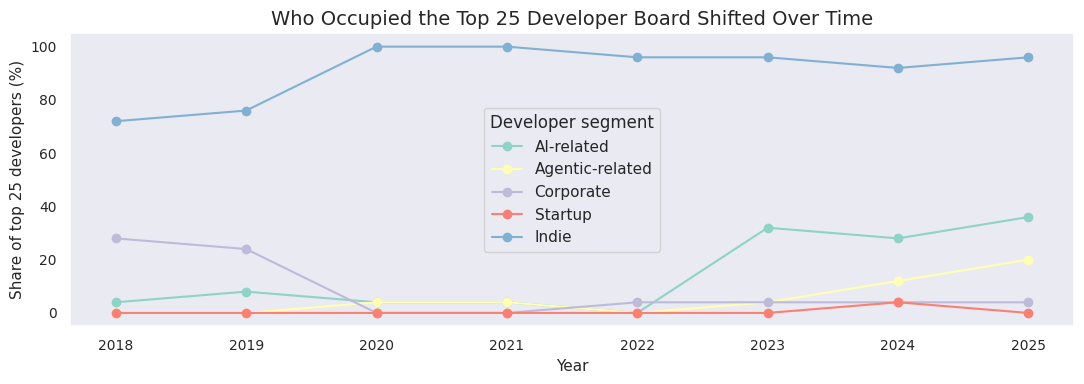

In [26]:
ax = developer_ai_share.plot(marker="o", figsize=(11, 4))
ax.set_title("Who Occupied the Top 25 Developer Board Shifted Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Share of top 25 developers (%)")
ax.legend([
    "AI-related",
    "Agentic-related",
    "Corporate",
    "Startup",
    "Indie",
], title="Developer segment")
plt.tight_layout()
plt.show()

The top developers of each year tell a similar, AI-adjacent story:
- In **2018-2019**, tech giants made up a large portion of the top open-source contributors.

- In **2020**, there was strangely a dropoff in corporate appearances on the trending developers page. This may have been caused by a shift in internal GitHub policy, but it could also be indicative of an era shift where frameworks were now well established and the majority of open-source content was now being sustained by indie developers who would utilize these frameworks as building blocks.

- From **2022** onward, we see a sharp increase in AI and agentic-related developers.

- Corporate contributions begin to slightly increase again in **2022**.

- Interestingly, startup contributions were close to nonexistent prior to **2023**. However, in **2024**, they actually matched corporate contributions. This could be indicative of agentic development opening the door for an influx of open-source startups.

I don't think that this data necessarily proves that large-company engineers are contributing less to open-source. We have no way of actually knowing the employment background of developers that were classified as "indie". What it is indicative of is that GitHub popularity has slowly become more attached to named project contributors, especially now in an era where a single developer has the capacity to establish an entire community hub with the help of agentic development.

## 4. April 4, 2026: The Snapshot of Today

Let's take one quick look at what the top 100 most starred repos look like today in terms of AI and agentic influence.


In [27]:
top_100_2026 = repos_2026.sort_values("rank").head(100).copy()
top_100_2026["repository"] = top_100_2026["dev_name"] + "/" + top_100_2026["repo_name"]
top_100_2026.head(10)

,rank,repo_name,star_count,fork_count,language,dev_name,issues,last_commit,is_ai,is_agentic,theme,repository
0,1,build-your-own-x,485939,45711,Markdown,codecrafters-io,243,2026-02-21 09:34:54+00:00,False,False,"[Learning resources, Developer tools]",codecrafters-io/build-your-own-x
1,2,awesome,451626,33946,NaN,sindresorhus,15,2026-04-02 16:30:33+00:00,False,False,[Other],sindresorhus/awesome
2,3,freeCodeCamp,440760,44007,TypeScript,freeCodeCamp,118,2026-04-03 22:40:32+00:00,False,False,[Learning resources],freeCodeCamp/freeCodeCamp
3,4,public-apis,418862,45543,Python,public-apis,3,2026-03-18 16:28:22+00:00,False,False,[Learning resources],public-apis/public-apis
4,5,free-programming-books,384969,66086,Python,EbookFoundation,35,2026-03-31 21:15:26+00:00,False,False,[Learning resources],EbookFoundation/free-programming-books
5,6,developer-roadmap,352153,43860,TypeScript,kamranahmedse,1,2026-04-03 15:34:48+00:00,False,False,[Learning resources],kamranahmedse/developer-roadmap
6,7,openclaw,347368,69305,TypeScript,openclaw,10616,2026-04-04 03:59:27+00:00,True,True,"[AI / ML, Agentic]",openclaw/openclaw
7,8,system-design-primer,341298,55194,Python,donnemartin,246,2026-03-20 01:52:19+00:00,False,False,[Learning resources],donnemartin/system-design-primer
8,9,coding-interview-university,340229,81860,NaN,jwasham,73,2025-08-28 14:42:47+00:00,False,False,[Learning resources],jwasham/coding-interview-university
9,10,awesome-python,290559,27570,Python,vinta,0,2026-04-03 08:18:40+00:00,False,False,"[Learning resources, Languages / libraries]",vinta/awesome-python


In [28]:
summary_rows = []

for n in [10, 20, 50, 100]:
    sample = top_100_2026.head(n)
    summary_rows.append(
        {
            "cut": f"Top {n} starred repos on 2026-04-04",
            "ai_count": int(sample["is_ai"].sum()),
            "ai_share": round(sample["is_ai"].mean() * 100, 1),
            "agentic_count": int(sample["is_agentic"].sum()),
            "agentic_share": round(sample["is_agentic"].mean() * 100, 1),
        }
    )

summary_2026 = pd.DataFrame(summary_rows)
summary_2026

,cut,ai_count,ai_share,agentic_count,agentic_share
0,Top 10 starred repos on 2026-04-04,1,10.0,1,10.0
1,Top 20 starred repos on 2026-04-04,1,5.0,1,5.0
2,Top 50 starred repos on 2026-04-04,11,22.0,6,12.0
3,Top 100 starred repos on 2026-04-04,25,25.0,16,16.0


In [29]:

top_ai_2026 = (
    top_100_2026.loc[top_100_2026["is_ai"], ["rank", "repository", "star_count", "language", "is_agentic"]]
    .sort_values("rank")
    .reset_index(drop=True)
)
top_ai_2026

,rank,repository,star_count,language,is_agentic
0,7,openclaw/openclaw,347368,TypeScript,True
1,21,tensorflow/tensorflow,194443,C++,False
2,26,Significant-Gravitas/AutoGPT,183115,Python,True
3,27,n8n-io/n8n,182368,TypeScript,True
4,34,ollama/ollama,167042,Go,False
5,35,AUTOMATIC1111/stable-diffusion-webui,162107,Python,False
6,37,huggingface/transformers,158766,Python,False
7,38,f/prompts.chat,157231,HTML,False
8,44,langflow-ai/langflow,146560,Python,True
9,49,anomalyco/opencode,136666,TypeScript,True


In [30]:
ai_language_mix = (
    top_ai_2026["language"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("language")
    .reset_index(name="repo_count")
)
ai_language_mix

,language,repo_count
0,Python,10
1,TypeScript,6
2,C++,2
3,Shell,2
4,Go,1
5,HTML,1
6,JavaScript,1
7,Unknown,1
8,Jupyter Notebook,1


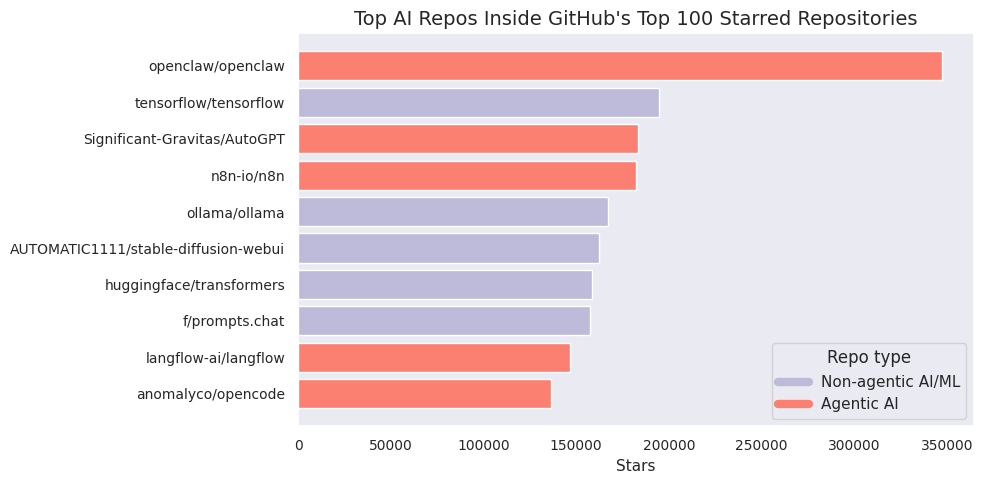

In [31]:
plot_df = top_ai_2026.head(10).sort_values("star_count")
theme_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = plot_df["is_agentic"].map({True: theme_colors[3], False: theme_colors[2]})

plt.figure(figsize=(10, 5))
plt.barh(plot_df["repository"], plot_df["star_count"], color=colors)
plt.title("Top AI Repos Inside GitHub's Top 100 Starred Repositories")
plt.xlabel("Stars")
plt.ylabel("")
plt.legend([
    plt.Line2D([0], [0], color=theme_colors[2], lw=6),
    plt.Line2D([0], [0], color=theme_colors[3], lw=6),
], ["Non-agentic AI/ML", "Agentic AI"], title="Repo type", loc="lower right")
plt.tight_layout()
plt.show()

This more grounded snapshot of **April 4th, 2026** actually even caught me by surprise:

Despite AI repos only really taking off about 3 years ago, they now (conservatively) make up **25% of the top 100** starred projects on GitHub. **More than half** of those projects are agentic-related.

Even with the AI hype, there's still some titans of the past that have yet to be dethrowned. The very top 10 remains dominated by educational and general utility repos such as `build-your-own-x`, `awesome`, `freeCodeCamp`, `public-apis`, `free-programming-books`, and `developer-roadmap`.

The language shift from Python to TypeScript also carries an interesting connotation to it. It seems that agentic developments are moreso focused on forward-facing utilities as opposed to the old data wrangling and modeling environment Python is dominant in. Still, I imagine it'd be tough to fully decouple ML from Python any time soon.


## Takeaway

A quick wrap up on our findings:

1. **2013-2017:** GitHub Trending was still largely about frameworks, frontend tools, and establishing the building blocks of web dev.

2. **2017-2022:** Open-source saw a strong flux in its collective goal to provide free, readily available educational resources to the public.

3. **Late 2022 to 2024:** Generative AI not bursted onto the scene *and* sustained a relatively high margin thereafter. 

4. **2024 to 2025:** the AI trend matured from models and prompt repos into more agentic, workflow-oriented, and developer-facing tools.

5. **Developer popularity shifted:** the leaderboard became more visibly centered on named maintainers and project creators, especially in AI ecosystems.

6. **As of April 4, 2026:** AI has firmly established itself among the top repos on GitHub. In the verified `top-100-stars` slice, about **a quarter** of the repos were clearly AI-related, and about **one in six** were agentic or workflow-oriented.